In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [7]:
dataset_id = "wikimedia/wikipedia"
configs_file = "config.json"
compression_methods = ["snappy", "gzip", "brotli", "lz4", "zstd"]
config_dict = json.load(open(configs_file, "r"))[dataset_id]['configs']
compress_methods_count = len(config_dict[0]['compress'])
size_dict = {
    "snappy": 0,
    "gzip": 0,
    "brotli": 0,
    "lz4": 0,
    "zstd": 0,
}
compress_size_list = [size_dict.copy() for _ in range(compress_methods_count)]

In [8]:
for config in config_dict:
    # print(f"config name: {config['file']}")
    for compression_method in compression_methods:
        size_dict[compression_method] += config[f'size_{compression_method}']
    for i, compress in enumerate(config['compress']):
        for compression_method in compression_methods:
            compress_size_list[i][compression_method] += compress[f'size_compression_{compression_method}']
    

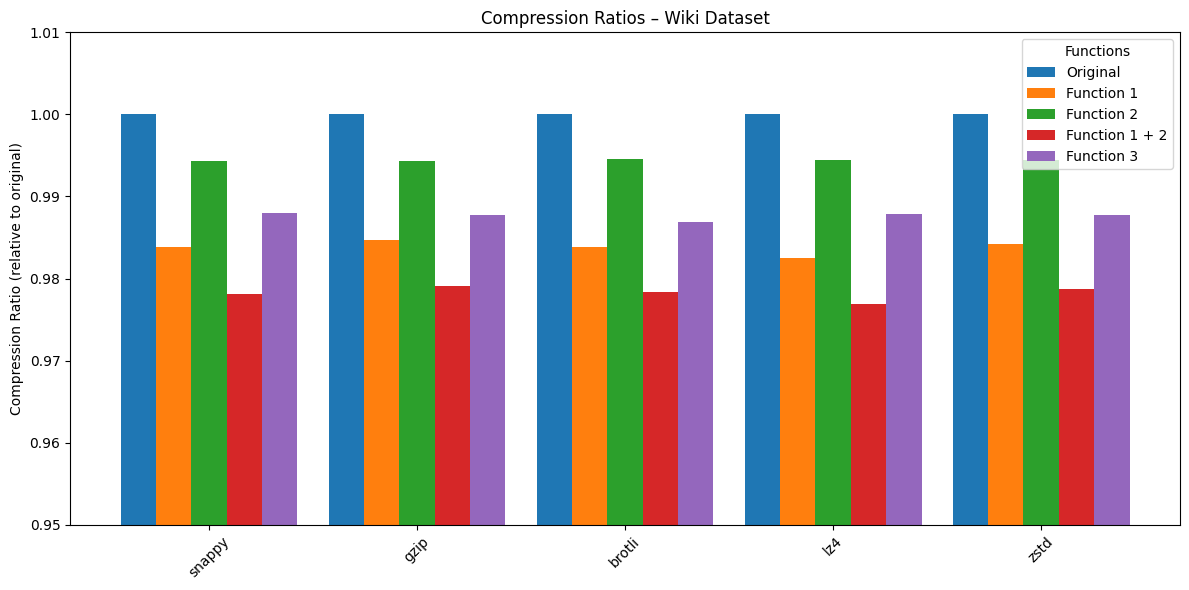

In [16]:
functions = ["Original", "Function 1", "Function 2", "Function 1 + 2", "Function 3"]
# compression_method = "snappy"
values = [size_dict[compression_method]]
# ori = values[0]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

x = np.arange(len(compression_methods))
bar_width = 0.17

plt.figure(figsize=(12, 6))

for f_idx, func in enumerate(functions):
    ratios = []
    for method in compression_methods:
        original = size_dict[method]
        if f_idx == 0:
            ratios.append(1.0)  # Original
        else:
            comp_size = compress_size_list[f_idx - 1][method]
            ratios.append(comp_size / original)
    
    positions = x + (f_idx - (len(functions) / 2)) * bar_width + bar_width / 2
    plt.bar(positions, ratios, bar_width, label=func, color=colors[f_idx])

plt.ylabel("Compression Ratio (relative to original)")
plt.title("Compression Ratios – Wiki Dataset")
plt.xticks(x, compression_methods, rotation=45)
plt.ylim(0.95, 1.01)
plt.legend(title="Functions")
plt.tight_layout()
plt.savefig("plots/compression_ratios_Wiki.png")
plt.show()


In [33]:
dataset_id = "HuggingFaceFW/fineweb"
configs_file = "config.json"
compression_methods = ["snappy", "gzip", "brotli", "lz4", "zstd"]
config_dict = json.load(open(configs_file, "r"))[dataset_id]['configs']
compress_methods_count = len(config_dict[0]['compress'])
size_dict = {
    "snappy": 0,
    "gzip": 0,
    "brotli": 0,
    "lz4": 0,
    "zstd": 0,
}
compress_size_list = [size_dict.copy() for _ in range(compress_methods_count)]

In [ ]:
for config in config_dict:
    # print(f"config name: {config['file']}")
    for compression_method in compression_methods:
        size_dict[compression_method] += config[f'size_{compression_method}']
    for i, compress in enumerate(config['compress']):
        for compression_method in compression_methods:
            compress_size_list[i][compression_method] += compress[f'size_compression_{compression_method}']


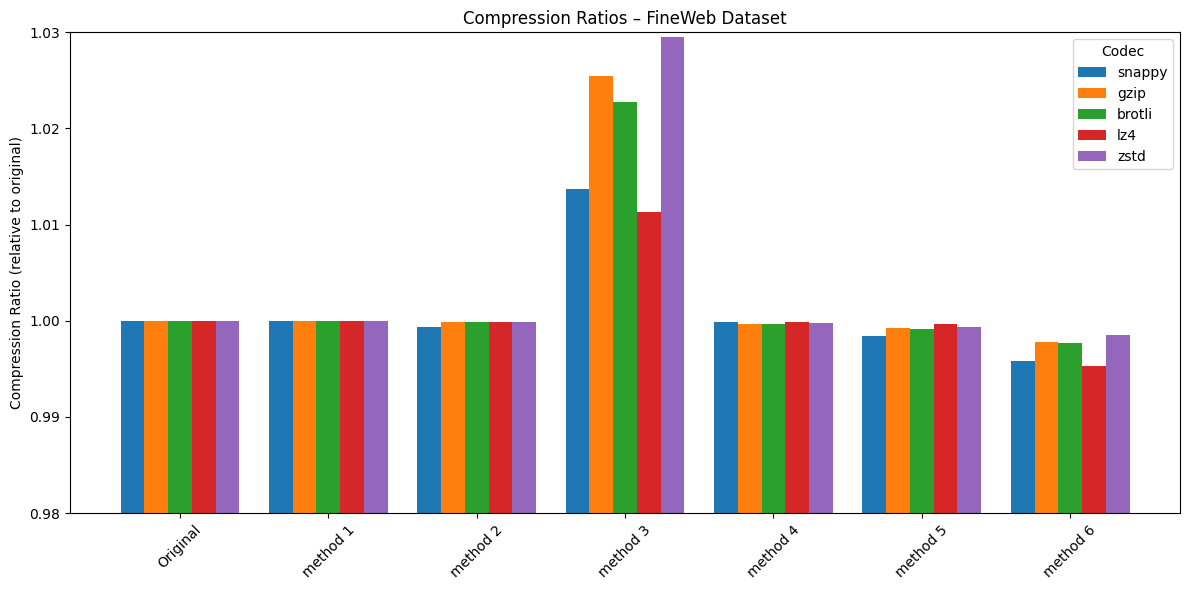

In [ ]:
categories = ["Original", "function 1", "function 2", "function 3", "function 4", "function 5", "function 6"]
# compression_method = "snappy"
values = [size_dict[compression_method]]
# ori = values[0]
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

x = np.arange(len(categories))
bar_width = 0.16

plt.figure(figsize=(12, 6))

for idx, method in enumerate(compression_methods):
    vals = [size_dict[method]] + [comp[method] for comp in compress_size_list]
    ori = vals[0]
    ratios = [v / ori for v in vals]
    
    positions = x + (idx - (len(compression_methods) / 2)) * bar_width + bar_width / 2
    plt.bar(positions, ratios, bar_width, label=method, color=colors[idx])

plt.ylabel("Compression Ratio (relative to original)")
plt.title("Compression Ratios – FineWeb Dataset")
plt.xticks(x, categories, rotation=45)
plt.ylim(0.98, 1.03)
plt.legend(title="Codec")
plt.tight_layout()
plt.show()